# 05 Decision Tree With Basic Image Features

This notebook compares an untuned `DecisionTreeClassifier` with a simply tuned tree using the existing basic image features. The goal is to reduce overfitting, not to maximize raw accuracy.

## 1. Project setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

## 2. Imports

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mse446_matplotlib")

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from src.extract_basic_features import BASIC_FEATURE_COLUMNS
from src.train_decision_tree import (
    CLASS_LABELS,
    CONFUSION_MATRIX_FIGURE,
    FEATURES_CSV,
    SCORES_CSV,
    TUNED_CONFUSION_MATRIX_FIGURE,
    TUNED_SCORES_CSV,
    evaluate_model,
    make_model,
    print_overfitting_summary,
    tune_decision_tree,
)
from src.train_logistic_regression import choose_group_split, load_features

## 3. Paths and configuration

In [3]:
print(f"Basic features CSV: {FEATURES_CSV}")
print(f"Untuned scores CSV: {SCORES_CSV}")
print(f"Tuned scores CSV: {TUNED_SCORES_CSV}")

Basic features CSV: /home/jp/MSE446_Nanoparticle_Ordering/data/features_basic.csv
Untuned scores CSV: /home/jp/MSE446_Nanoparticle_Ordering/results/model_scores_decision_tree_basic.csv
Tuned scores CSV: /home/jp/MSE446_Nanoparticle_Ordering/results/model_scores_decision_tree_tuned.csv


## 4. Load metadata

In [4]:
features = load_features(FEATURES_CSV)
features.head()

,filename,label,sample,area,area_group,kv,mm,mag,param_group,mean_intensity,...,min_intensity,max_intensity,p10_intensity,p25_intensity,p50_intensity,p75_intensity,p90_intensity,entropy,bright_pixel_ratio,edge_density
0,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.354890,...,0.160784,0.964706,0.266667,0.298039,0.345098,0.396078,0.447059,6.260059,0.099014,0.161224
1,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.414923,...,0.094118,1.000000,0.329412,0.376471,0.407843,0.447059,0.486275,6.191408,0.098190,0.113770
2,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.311404,...,0.141176,1.000000,0.247059,0.266667,0.286275,0.317647,0.423529,5.814114,0.097717,0.160583
3,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.326249,...,0.113725,1.000000,0.235294,0.266667,0.313726,0.368627,0.419608,6.261398,0.098694,0.164108
4,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.260067,...,0.000000,1.000000,0.117647,0.176471,0.235294,0.294118,0.415686,6.846660,0.099258,0.171616


## 5. Sanity checks

In [5]:
print(f"Rows: {len(features)}")
print("Label counts:")
print(features["label"].value_counts().sort_index())
print(f"Image feature columns: {len(BASIC_FEATURE_COLUMNS)}")
assert set(BASIC_FEATURE_COLUMNS).issubset(features.columns)
assert features["area_group"].notna().all()

Rows: 1000
Label counts:
label
disordered    250
ordered       750
Name: count, dtype: int64
Image feature columns: 12


## 6. Main analysis

The held-out split is selected using the same grouped split helper as Logistic Regression. Hyperparameter tuning uses `GroupKFold` only inside the training split, scored with macro F1.

In [6]:
train_idx, test_idx, selected_seed, split_distance = choose_group_split(features)

groups = features["area_group"]
assert set(groups.iloc[train_idx]).isdisjoint(set(groups.iloc[test_idx]))

X = features[BASIC_FEATURE_COLUMNS]
y = features["label"]
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
train_groups = groups.iloc[train_idx]

basic_scores, basic_report, basic_matrix, basic_figure = evaluate_model(
    make_model(),
    "decision_tree_basic",
    X_train,
    X_test,
    y_train,
    y_test,
    selected_seed,
    split_distance,
    CONFUSION_MATRIX_FIGURE,
    "Decision tree basic",
)

search = tune_decision_tree(X_train, y_train, train_groups)
tuned_scores, tuned_report, tuned_matrix, tuned_figure = evaluate_model(
    search.best_estimator_,
    "decision_tree_tuned",
    X_train,
    X_test,
    y_train,
    y_test,
    selected_seed,
    split_distance,
    TUNED_CONFUSION_MATRIX_FIGURE,
    "Decision tree tuned",
    float(search.best_score_),
    search.best_params_,
)

tuned_scores

,model,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_macro_precision,macro_precision,train_macro_recall,macro_recall,train_macro_f1,macro_f1,disordered_recall,selected_split_seed,split_distribution_distance,best_cv_macro_f1,best_params,train_size,test_size
0,decision_tree_tuned,0.929577,0.858108,0.913928,0.824324,0.901652,0.808333,0.913928,0.824324,0.907533,0.815691,0.756757,140,0.0,0.738853,"{'criterion': 'entropy', 'max_depth': 8, 'min_...",852,148


## 7. Results/figures


Untuned decision tree train vs test overfitting check:
train accuracy: 1.0000
test accuracy: 0.8311
train balanced accuracy: 1.0000
test balanced accuracy: 0.7703
train macro F1: 1.0000
test macro F1: 0.7727

Tuned decision tree train vs test overfitting check:
train accuracy: 0.9296
test accuracy: 0.8581
train balanced accuracy: 0.9139
test balanced accuracy: 0.8243
train macro F1: 0.9075
test macro F1: 0.8157
Best CV macro F1: 0.7389
Best params: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}

Untuned report:
              precision    recall  f1-score   support

  disordered       0.67      0.65      0.66        37
     ordered       0.88      0.89      0.89       111

    accuracy                           0.83       148
   macro avg       0.78      0.77      0.77       148
weighted avg       0.83      0.83      0.83       148

Tuned report:
              precision    recall  f1-score   support

  disordered       0.70      0.76      0.73  

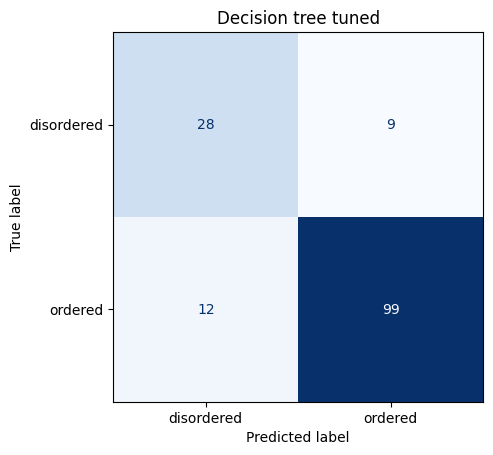

In [7]:
basic_scores.to_csv(SCORES_CSV, index=False)
tuned_scores.to_csv(TUNED_SCORES_CSV, index=False)

print_overfitting_summary(basic_scores, "Untuned decision tree")
print_overfitting_summary(tuned_scores, "Tuned decision tree")
print("Best CV macro F1:", round(search.best_score_, 4))
print("Best params:", search.best_params_)
print("\nUntuned report:")
print(basic_report)
print("Tuned report:")
print(tuned_report)
print(f"Saved untuned scores to {SCORES_CSV}")
print(f"Saved tuned scores to {TUNED_SCORES_CSV}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    search.best_estimator_.predict(X_test),
    labels=CLASS_LABELS,
    cmap="Blues",
    colorbar=False,
)
plt.title("Decision tree tuned")
plt.show()

## 8. Notes for report

- The untuned tree is expected to overfit if train metrics are much higher than test metrics.
- The tuned tree restricts complexity using depth and sample-count controls.
- This step still uses only basic image features and does not add RandomForest, SVC, KNN, HOG, graph features, or CNNs.